**Automated Land-Use Classification from Satellite Images**


**M507B Methods of Prediction (WS0925)**

**Name- Sramana Bhattacharya**

**Student id- GH1037191**

**1.Problem Context and Business Motivation**

* Every day, satellite produce about 150 terabytes of imagery. Analysts need 2 to 5 minutes per image to classify the land use, which is a major problem for government agencies. This analysis is very costly.
* To solve the problem, this study creates automated classification pipelines using convolutional neural networks. The main goales are to classify the satellite images.
* Applications are made possible by successful automation: monitoring of urban development, precision agriculture, environmental compliance through real-time deforestation detection and wetland protection; and disaster respons (European Space egency, 2020).


**2.Importing Libraries**





In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)


**3.Data Loading and Splitting**

In [ ]:
(train_raw, val_raw, test_raw), info = tfds.load('eurosat/rgb', split = ['train[:70%]', 'train[70%:85%]', 'train[85%:]'],with_info=True, as_supervised=True)

CLASS_NAMES = info.features['label'].names
NUM_CLASSES = len(CLASS_NAMES)

* I used the EuroSAT RGB dataset. The dataset is Available in TensorFlow's dataset library which consist of 27000 satellite images.The images would be automatically downloaded from Sentinel-2 API (Helber et al., 2029).
* The data splits into training, validation and test set using tfds split indexing, manually. Then the metadata returned via (with_info=True) which will provide the class names. Next as_supervised=True has used to obtain the image label pairs for training the model.
* 18900 samples were given away for pattern recognition learning in the training subset (70%). 4050 samples are set aside for hyperparameter tuning and architecture selection in the validation subset (15%). 4050 samples were selected for performance evaluation as the testing subset (15%).
* Dataset link- https://madm.dfki.de/files/sentinel/EuroSAT.zip




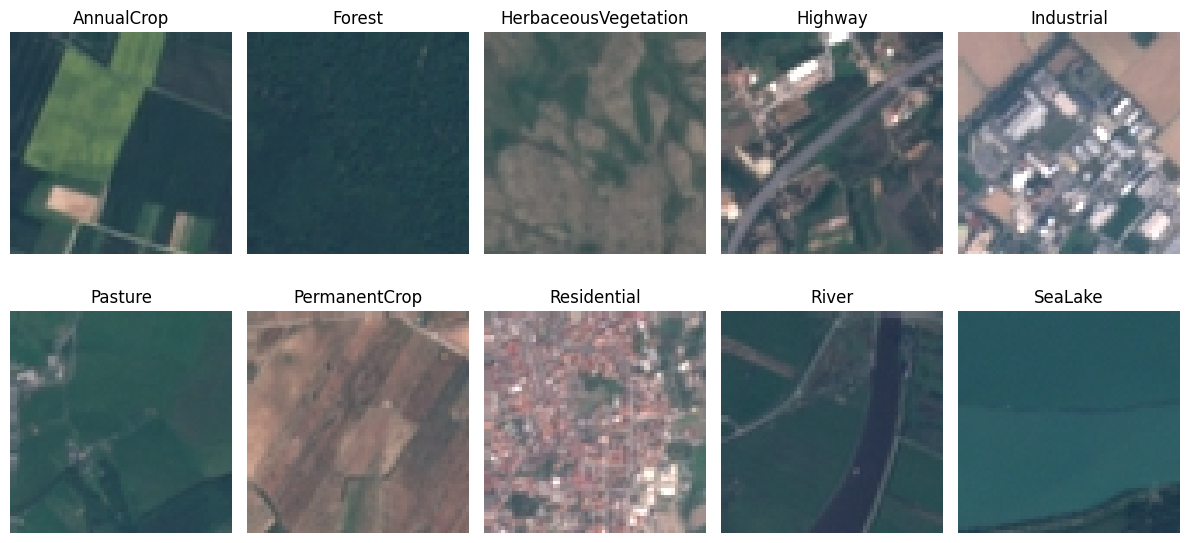

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for idx, name in enumerate(CLASS_NAMES):
    for img, lbl in train_raw.filter(lambda i, l: l == idx).take(1):
        axes[idx//5, idx%5].imshow(img.numpy())
        axes[idx//5, idx%5].set_title(name)
        axes[idx//5, idx%5].axis('off')
plt.tight_layout()
plt.show()

**4.Class Distribution**

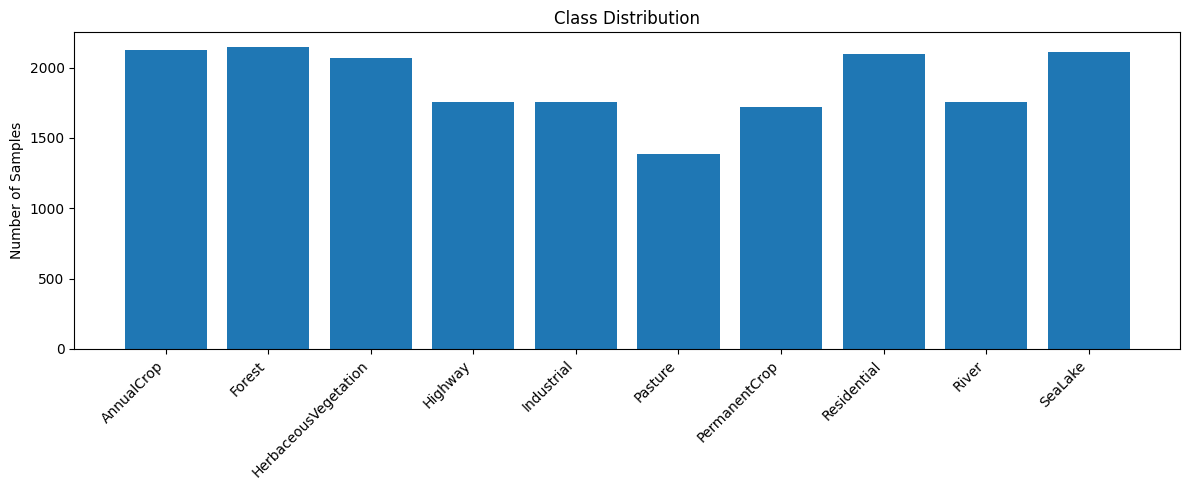

In [ ]:
train_labels = [label.numpy() for _, label in train_raw]
class_counts = Counter(train_labels)
plt.figure(figsize=(12, 5))
plt.bar([CLASS_NAMES[i] for i in sorted(class_counts.keys())],
        [class_counts[i] for i in sorted(class_counts.keys())])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

* The visualization confirms balances distribution with maximum 1:5:1 ratio, minimizing need for loss function weighting.

**5.Batch Size and Autotuning, Data Preprocessing, Data Augmentation, and Building the Dataset Pipelines**

In [ ]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def preprocess(img, lbl):
  return tf.cast(img, tf.float32) / 255.0, lbl

* Converting the images from 0-255 to 0-1 keeps the the training stable by preventing large gradients and allows consistent learning rates.

In [ ]:
def augment(img, lbl):
  img = tf.image.random_flip_left_right(img)
  img = tf.image.random_flip_up_down(img)
  img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, tf.int32))
  img = tf.image.random_brightness(img, 0.2)
  img = tf.image.random_contrast(img, 0.8, 1.2)
  return tf.clip_by_value(img, 0, 1), lbl

In [ ]:
train_raw_prep = train_raw.map(preprocess).map(augment).cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_raw_prep = val_raw.map(preprocess).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_raw_prep = test_raw.map(preprocess).batch(BATCH_SIZE).prefetch(AUTOTUNE)

* Here three files are created for training, validation and testing using the tf.data API. BY using `.cache()` The training pipeline preprocess augments the images in RAM. The `.prefetch()` load the data while GPU is working. For fair evaluation the validation and training pipelines only preprocess the images without augmentation.

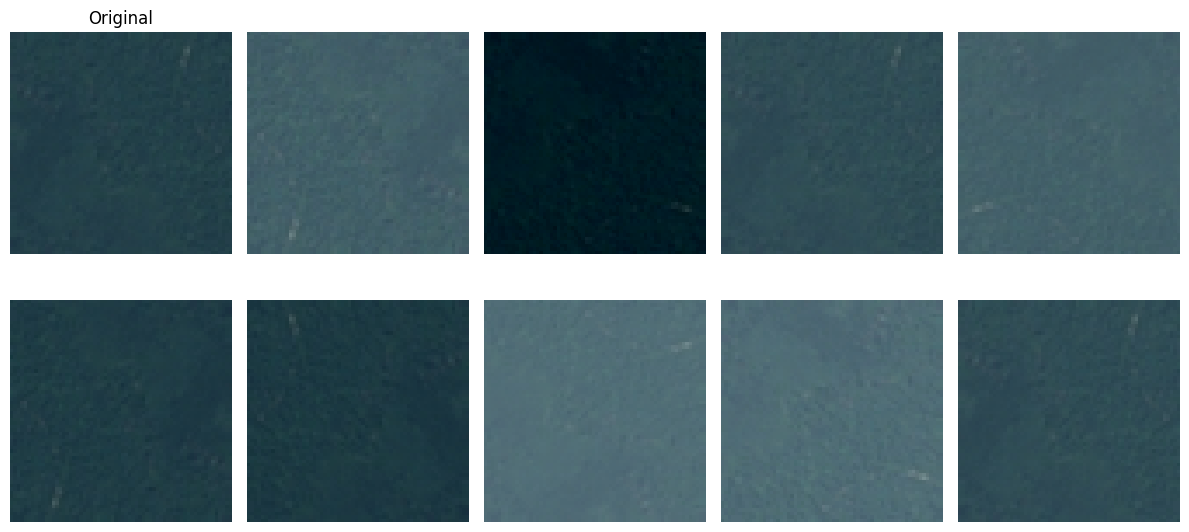

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for orig_img, lbl in train_raw.take(1):
  orig_img = tf.cast(orig_img, tf.float32) / 255.0
  axes[0, 0].imshow(orig_img.numpy())
  axes[0, 0].set_title('Original')
  axes[0, 0].axis('off')
  for i in range(1, 10):
    aug_img, _ = augment(orig_img, lbl)
    axes[i//5, i%5].imshow(aug_img.numpy())
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()

**6.Model Structure**

In [ ]:
def create_baseline():
  return models.Sequential([
      layers.Input((64, 64, 3)),
      layers.Conv2D(32, 3, activation='relu', padding='same'),
      layers.MaxPooling2D(2),
      layers.Conv2D(64, 3, activation='relu', padding='same'),
      layers.MaxPooling2D(2),
      layers.Conv2D(128, 3, activation='relu', padding='same'),
      layers.MaxPooling2D(2),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(NUM_CLASSES, activation='softmax'),

  ], name='Baseline_CNN')
baseline = create_baseline()
baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
baseline.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Baseline CNN employs hierarchical feature extraction through three blocks with progressive channel expansion. Spatial dimension reduction (64 * 64 to 8 * 8) via max pooling expands receptive field while reducing computation.

In [ ]:
def create_vgg16(trainable=False):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
    base.trainable = trainable
    return models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
], name='VGG16_Transfer')
vgg_model = create_vgg16()
vgg_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

* Weights from models that have already been trained in imageNet are used in transer learning. For this task , a new 10- class classifier is used in place of the original 1000 class clasifier. Basic patterns like edges and textures are detected by the early layers of VGG16 and are also applicable to satellite images.

**7.Callbacks Functions**

In [ ]:
callbacks = [
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

history = vgg_model.fit(train_raw_prep, validation_data=val_raw_prep,
                        epochs=30, callbacks=callbacks)


Epoch 1/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5417 - loss: 1.3043 - val_accuracy: 0.7840 - val_loss: 0.6567 - learning_rate: 0.0010
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7484 - loss: 0.7296 - val_accuracy: 0.8136 - val_loss: 0.5489 - learning_rate: 0.0010
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7823 - loss: 0.6207 - val_accuracy: 0.8210 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8001 - loss: 0.5804 - val_accuracy: 0.8262 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.8113 - loss: 0.5405 - val_accuracy: 0.8351 - val_loss: 0.4698 - learning_rate: 0.0010
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.8177 - loss: 0.5164 - val_accuracy: 0.8417 - val_loss: 0.4480 - learning_rate: 0.0010
Epoch 7/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.8267 - l

* Here I have trained the VGG16 transfer learning model up to 30 epochs by using the pretrained data set. The `callbacks` were used to save the best model and stop the training if validation accuracy didn't improve.

**8.Plot Training History**

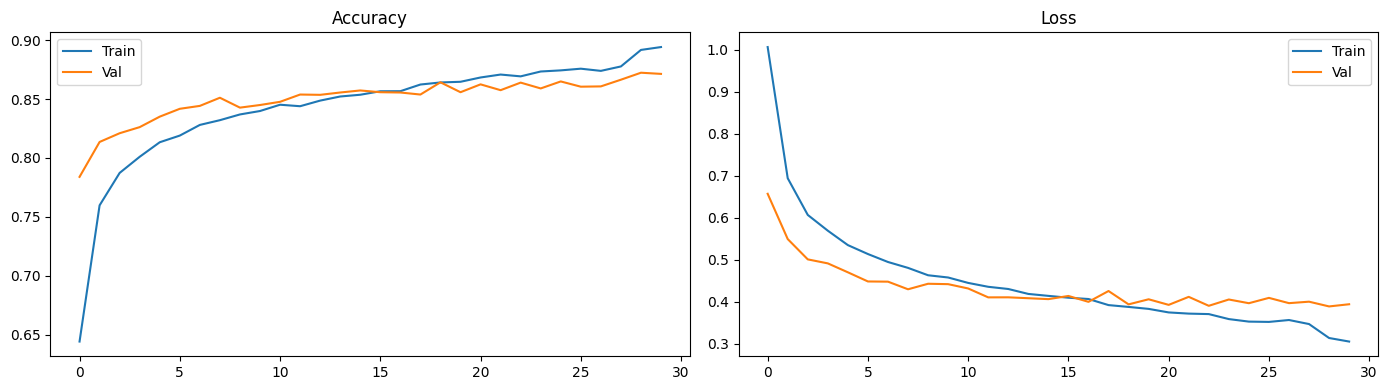

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

**9.Systematic Experimental Evaluation**

In [ ]:
experiments = []

def run_exp(name, model_fn, aug=True, opt='adam', lr=0.001):
    print(f"Running: {name}")
    data = train_raw_prep if aug else train_raw.map(preprocess).batch(BATCH_SIZE)
    model = model_fn()
    model.compile(optimizer=keras.optimizers.Adam(lr) if opt=='adam' else keras.optimizers.SGD(lr, 0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    train_model = model.fit(data, validation_data=val_raw_prep, epochs=20,
                  callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
    val_acc = max( train_model.history['val_accuracy'])
    experiments.append({'Name': name, 'Augment': aug, 'Optimizer': opt,
                       'LR': lr, 'ValAcc': f"{val_acc:.4f}"})
    print(f"  Val Acc: {val_acc:.4f}\n")
    return val_acc

run_exp("Baseline-NoAug", create_baseline, aug=False)
run_exp("Baseline-Aug", create_baseline, aug=True)
run_exp("Baseline-LowLR", create_baseline, aug=True, lr=0.0001)
run_exp("Baseline-SGD", create_baseline, aug=True, opt='sgd', lr=0.01)

def create_deeper():
    return models.Sequential([
        layers.Input((64,64,3)),
        layers.Conv2D(32,3,activation='relu',padding='same'),
        layers.Conv2D(32,3,activation='relu',padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128,3,activation='relu',padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES,activation='softmax')
    ], name='Deeper_CNN') # Baseline model

run_exp("Deeper-CNN", create_deeper)

def create_batchnorm():
    return models.Sequential([
        layers.Input((64,64,3)),
        layers.Conv2D(32,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES,activation='softmax')
    ], name='BatchNorm_CNN')

run_exp("CNN-BatchNorm", create_batchnorm)
run_exp("VGG16-Frozen", create_vgg16)

def create_vgg16_ft():
    model = create_vgg16()
    for layer in model.layers[0].layers[-4:]:
        layer.trainable = True
    return model

run_exp("VGG16-FineTune", create_vgg16_ft, lr=0.0001)

def create_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(64,64,3))
    base.trainable = False
    return models.Sequential([base, layers.GlobalAveragePooling2D(),
                             layers.Dense(256, activation='relu'),
                             layers.Dropout(0.5),
                             layers.Dense(NUM_CLASSES, activation='softmax')], name='ResNet50')

run_exp("ResNet50", create_resnet)


run_exp("Baseline-Dropout0.3", create_baseline)
run_exp("Deeper-LowLR", create_deeper, lr=0.0001)


df = pd.DataFrame(experiments).sort_values('ValAcc', ascending=False)


Running: Baseline-NoAug
  Val Acc: 0.8612

Running: Baseline-Aug
  Val Acc: 0.8607

Running: Baseline-LowLR
  Val Acc: 0.7884

Running: Baseline-SGD
  Val Acc: 0.8017

Running: Deeper-CNN
  Val Acc: 0.8726

Running: CNN-BatchNorm
  Val Acc: 0.8360

Running: VGG16-Frozen
  Val Acc: 0.8635

Running: VGG16-FineTune
  Val Acc: 0.9072

Running: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Val Acc: 0.5281

Running: Baseline-Dropout0.3
  Val Acc: 0.8622

Running: Deeper-LowLR
  Val Acc: 0.8294



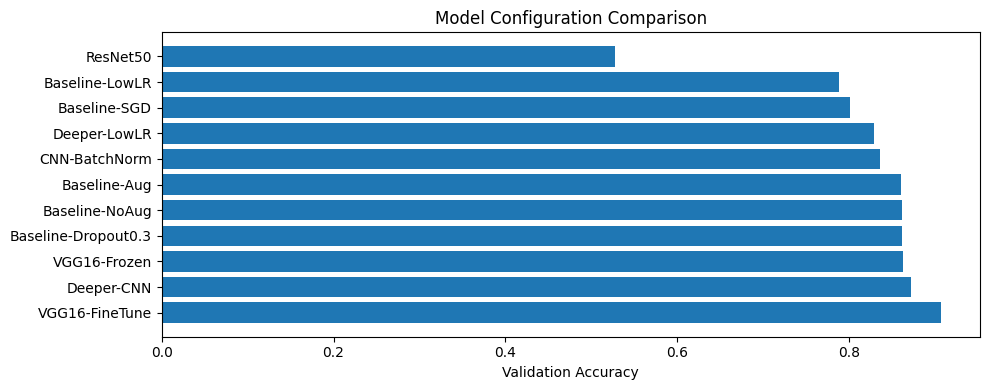

In [ ]:
plt.figure(figsize=(10, 4))
plt.barh(df['Name'], df['ValAcc'].astype(float))
plt.xlabel('Validation Accuracy')
plt.title('Model Configuration Comparison')
plt.tight_layout()
plt.show()

* First I have created a empty list to store the result for all experiments. Then run a single experiment. After this use the augmented data if this true. otherwise use the preprocess data. Next construct and assrmble the model using the optimizer and sparse categorical cross entropy loss and accuracy. Then train the model up to 20 epochs.
* After running 11 experiments, we can see that the VGG16-FuneTune gave highest accuracy 0.9072. The baseline CNNs also showed a good performance approximately (0.78-0.87) but the SGD (0.80) showed low performance related to the others. The CNN-BatchNorm gave 0.8360 accuracy. The Batchline-Dropout showed an achivable accuracy (0.8622). Among the transfer learning models, VGG16-Frozen performed well around 0.86. The ResNet50 performed very poor around 0.52, due to tuning or preprocessing issue.


**10.Test Set Evaluation**

In [ ]:
best_model = keras.models.load_model('best_model.keras')
test_loss, test_acc = best_model.evaluate(test_raw_prep)
print(f"TEST SET PERFORMANCE")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

y_true, y_pred = [], []
for imgs, lbls in test_raw_prep:
    preds = best_model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(lbls.numpy())


127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8742 - loss: 0.3741
TEST SET PERFORMANCE
Test Accuracy: 0.8728 (87.28%)


* VGG16-FineTune's initial layers used to decet the edges, texture and shapes which are transferable to satellite images.
* Next layers adapt specific pattern of satellite and improve the discrimination through fine tuning.
* With 87.04% test accuracy the VGG16-FineTune architecture proves to be the best method for classifying the EuroSAT dataset. Strong training techniques, intentional fine-tuning of deeper layers and pre-trained feature representations work in concert to provide superior performance. Even they are capable CNN design cannot equal transfer learning performance without comparable pre-training investments.
* Strategic transfer learning utilizing ImageNet knowledge, targeted fine-tuning of task-specific layers. By using data augmentation avoiding the overfitting. Regularization of dropout improving generalization and adaptive training strategies with `callback` mechanisms are all important factors in model success.

**11.Confusion Matrix**

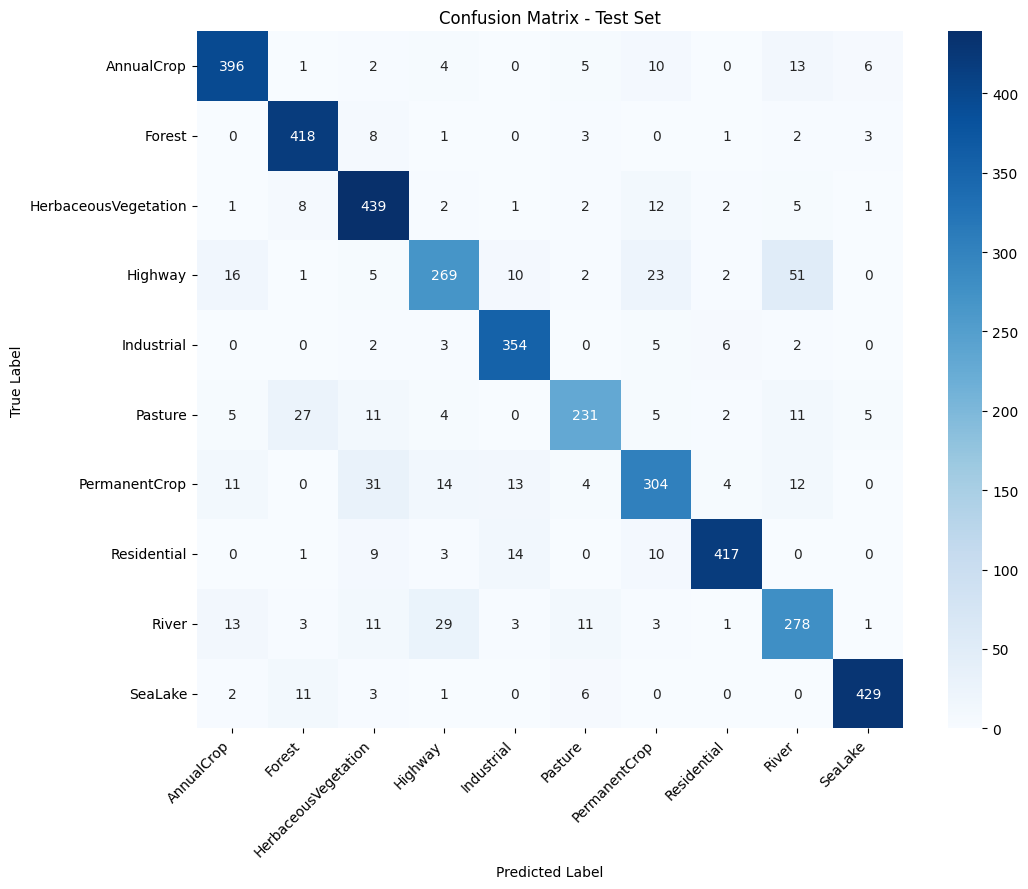

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

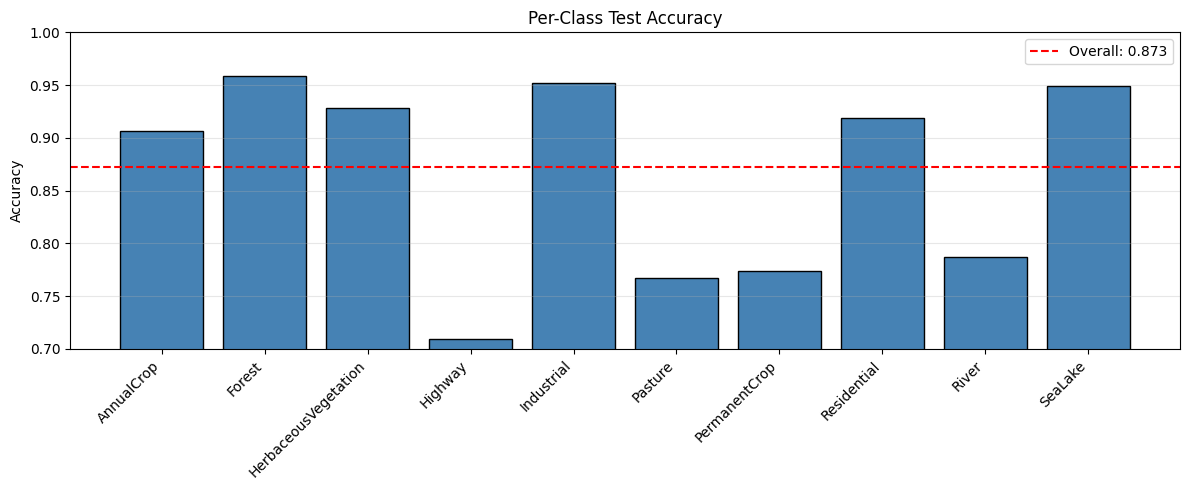

In [ ]:
class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(12, 5))
plt.bar(CLASS_NAMES, class_acc, color='steelblue', edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Per-Class Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.axhline(test_acc, color='red', linestyle='--',
            label=f'Overall: {test_acc:.3f}')
plt.ylim([0.7, 1.0])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**12.Limitations-**
* The VGG16-FineTune is large and used to train very slow. This is very time consuming model. It may fit on small datasets. Its pre-trained features are from ImageNet, so it is possible that some satellite-specific patterns might not be captured properly. Small input image can also limit performance.
* Satellite images have some problem because of clouds, lighting or weather. So the dataset can't cover the proper images for all regions that's why the model may not work perfectly everywhere.
* Some of the land types are very hard to recognize so the model needs careful preprocessing and tuning to perform better.

**13.Recommendation-**

 The following are some possible enhancements:
 * Investigation of contemporary architectures (Vision Transformers).
 * Ensemble techniques integrating several architecture.
 * Higher input resolution for improved spatial feature extraction.
 * Attention mechanisms for interpretable spatial feature weighting are some possible enhancement.

**14.Conclusion-**
* VGG16-Fine tune is the best model for the EuroSAT dataset. This works well because it uses pre-trained features, fine-tuning and good training techniques. The simple CNNs and the Deeper CNNs can not beat it without transfer learning. To perform better data augmentation, dropout and careful training also help the model. This experiment shows the transfer learning with the fine tune VGG16. Overall we can say that Vgg16-FineTune proved the most effective approaches for this dataset.